In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/telecom_customer_churn_feature_engineering.csv')
df.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


In [3]:
df.tail()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
1195,11196,2022-04-10,48,Male,Gujranwala,Master,Employed,8193.0,10223.0,5.8,334.0,6-Month,1,Coverage is poor in my location,1
1196,11197,2022-04-11,54,Male,Lahore,Bachelor,Student,32480.0,3320.0,9.9,47.0,Monthly,3,Too expensive compared to competitors,1
1197,11198,2022-04-12,34,Male,Quetta,Primary,Student,42000.0,8147.0,33.0,96.0,12-Month,1,Too expensive compared to competitors,0
1198,11199,2022-04-13,20,Male,Multan,Secondary,Employed,80554.0,8427.0,14.4,157.0,Monthly,1,Service is unreliable during peak hours,0
1199,11200,2022-04-14,28,Male,Quetta,Bachelor,Employed,49647.0,4074.0,16.0,126.0,12-Month,1,Service is unreliable during peak hours,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1200 non-null   int64  
 1   signup_date        1200 non-null   object 
 2   age                1200 non-null   int64  
 3   gender             1200 non-null   object 
 4   city               1200 non-null   object 
 5   education_level    1200 non-null   object 
 6   employment_status  1200 non-null   object 
 7   monthly_income     1200 non-null   float64
 8   monthly_bill       1200 non-null   float64
 9   internet_usage_gb  1200 non-null   float64
 10  call_minutes       1200 non-null   float64
 11  contract_type      1200 non-null   object 
 12  support_tickets    1200 non-null   int64  
 13  customer_feedback  1200 non-null   object 
 14  churn              1200 non-null   int64  
dtypes: float64(4), int64(4), object(7)
memory usage: 140.8+ KB


In [5]:
df.shape

(1200, 15)

In [6]:
df.describe()

,customer_id,age,monthly_income,monthly_bill,internet_usage_gb,call_minutes,support_tickets,churn
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,10600.500000,43.483333,31155.975833,5939.150833,20.152417,182.830833,1.193333,0.350000
std,346.554469,15.205176,19351.937726,4046.473963,12.174714,106.567558,1.084098,0.477168
min,10001.000000,18.000000,4984.000000,710.000000,1.100000,14.000000,0.000000,0.000000
25%,10300.750000,30.000000,17795.000000,3291.750000,11.100000,106.000000,0.000000,0.000000
50%,10600.500000,43.000000,26628.000000,4871.000000,17.800000,164.000000,1.000000,0.000000
75%,10900.250000,57.000000,39886.250000,7485.500000,26.700000,235.000000,2.000000,1.000000
max,11200.000000,69.000000,209790.000000,36361.000000,82.200000,865.000000,6.000000,1.000000


In [7]:
df.isnull().sum()

,0
customer_id,0
signup_date,0
age,0
gender,0
city,0
education_level,0
employment_status,0
monthly_income,0
monthly_bill,0
internet_usage_gb,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["churn"].value_counts()

,count
churn,
0,780
1,420


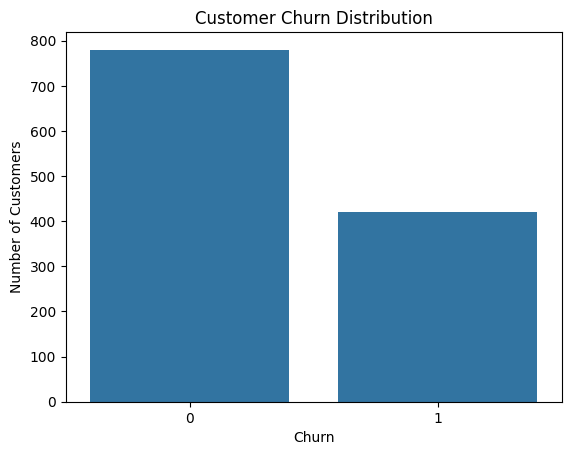

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x="churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
df["contract_type"].value_counts()

,count
contract_type,
Monthly,569
12-Month,345
6-Month,286


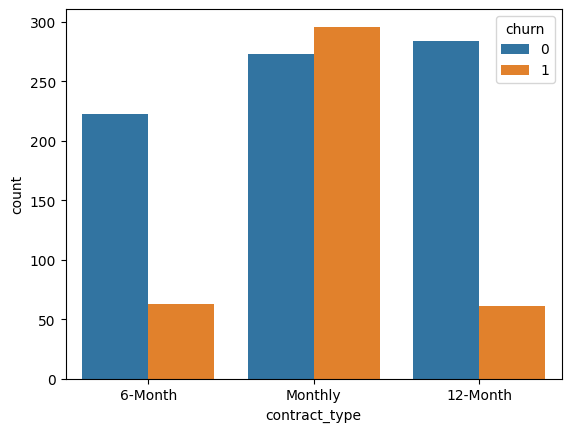

In [12]:
sns.countplot(data=df, x="contract_type", hue="churn")
plt.show()

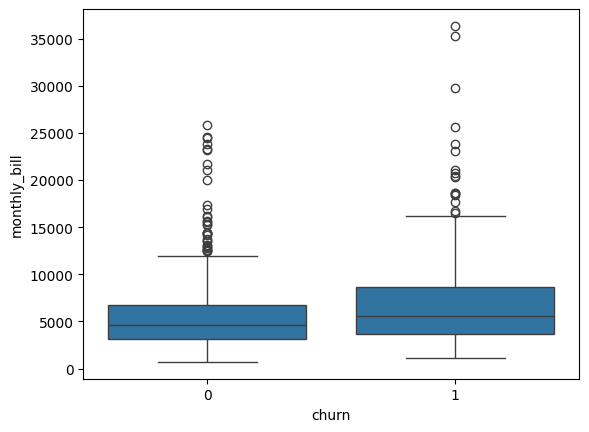

In [13]:
sns.boxplot(data=df, x="churn", y="monthly_bill")
plt.show()

In [14]:
df.corr(numeric_only=True)

,customer_id,age,monthly_income,monthly_bill,internet_usage_gb,call_minutes,support_tickets,churn
customer_id,1.000000,-0.013386,-0.021401,0.006077,0.015020,-0.006731,0.001576,0.005447
age,-0.013386,1.000000,-0.012637,0.015841,0.003579,0.030600,-0.008203,0.021151
monthly_income,-0.021401,-0.012637,1.000000,0.015506,0.014122,-0.013300,-0.030976,-0.169587
monthly_bill,0.006077,0.015841,0.015506,1.000000,-0.019827,0.034687,-0.004374,0.179801
internet_usage_gb,0.015020,0.003579,0.014122,-0.019827,1.000000,-0.000600,-0.009925,-0.089472
call_minutes,-0.006731,0.030600,-0.013300,0.034687,-0.000600,1.000000,-0.018039,0.046073
support_tickets,0.001576,-0.008203,-0.030976,-0.004374,-0.009925,-0.018039,1.000000,0.626855
churn,0.005447,0.021151,-0.169587,0.179801,-0.089472,0.046073,0.626855,1.000000


In [15]:
df = df.drop("customer_id", axis=1)

In [16]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [17]:
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month

In [18]:
df = df.drop([ "signup_date"], axis=1)

In [19]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_columns = [
    "gender",
    "city",
    "education_level",
    "employment_status",
    "contract_type",
    "customer_feedback"
]
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)
encoded = encoder.fit_transform(df[categorical_columns])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=df.index
)
df = pd.concat(
    [df.drop(categorical_columns, axis=1), encoded_df],
    axis=1
)
df.head()

,age,monthly_income,monthly_bill,internet_usage_gb,call_minutes,support_tickets,churn,signup_year,signup_month,gender_Female,...,customer_feedback_Billing issues occurred multiple times,customer_feedback_Coverage is poor in my location,customer_feedback_Customer support was helpful,customer_feedback_Frequent call drops in my area,customer_feedback_Happy with data packages,customer_feedback_Internet speed is very slow,customer_feedback_Network quality is good overall,customer_feedback_Satisfied with the service,customer_feedback_Service is unreliable during peak hours,customer_feedback_Too expensive compared to competitors
0,65,57643.0,10049.0,5.8,52.0,1,0,2019,1,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22,18207.0,2752.0,11.9,22.0,2,0,2019,1,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,43,13075.0,3155.0,40.0,87.0,0,0,2019,1,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,21,38890.0,5859.0,8.5,147.0,2,0,2019,1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,37,17475.0,5106.0,3.3,183.0,0,0,2019,1,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)
print(y_pred_lr)

[1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1
 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
y_pred_dt = decision_tree_model.predict(X_test)
print(y_pred_dt)

[0 1 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 1
 0 1 1 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0
 0 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 1 0 0 0 0 1 1 0
 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1
 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0]


In [25]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)
print(y_pred_rf)

[0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1
 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0
 0 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 0
 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0]


In [26]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(y_pred_xgb)

[0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1
 0 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0
 0 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 1 0
 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1
 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0]


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [28]:
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
Accuracy: 0.7291666666666666
Precision: 0.6727272727272727
Recall: 0.44047619047619047
F1 Score: 0.5323741007194245
ROC-AUC: 0.9464285714285714


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [29]:
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Decision Tree
Accuracy: 0.9583333333333334
Precision: 0.9111111111111111
Recall: 0.9761904761904762
F1 Score: 0.9425287356321839
ROC-AUC: 0.9624542124542125


In [30]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest
Accuracy: 0.9625
Precision: 1.0
Recall: 0.8928571428571429
F1 Score: 0.9433962264150944
ROC-AUC: 0.9959935897435898


In [31]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost
Accuracy: 0.9708333333333333
Precision: 0.9425287356321839
Recall: 0.9761904761904762
F1 Score: 0.9590643274853801
ROC-AUC: 0.9982448107448108


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.729167   0.672727  0.440476  0.532374  0.946429
1        Decision Tree  0.958333   0.911111  0.976190  0.942529  0.962454
2        Random Forest  0.962500   1.000000  0.892857  0.943396  0.995994
3              XGBoost  0.970833   0.942529  0.976190  0.959064  0.998245


In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_model,
    params,
    cv=5,
    scoring="f1"
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
y_pred_best = best_model.predict(X_test)
print(y_pred_best)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
[0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1
 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0
 0 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 0
 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0]


In [34]:
import joblib
joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [41]:
pipeline.fit(X_train, y_train)
print("Pipeline trained successfully!")

Pipeline trained successfully!


In [42]:
import joblib
joblib.dump(pipeline, "churn_model.pkl")
print("Pipeline saved successfully!")

Pipeline saved successfully!


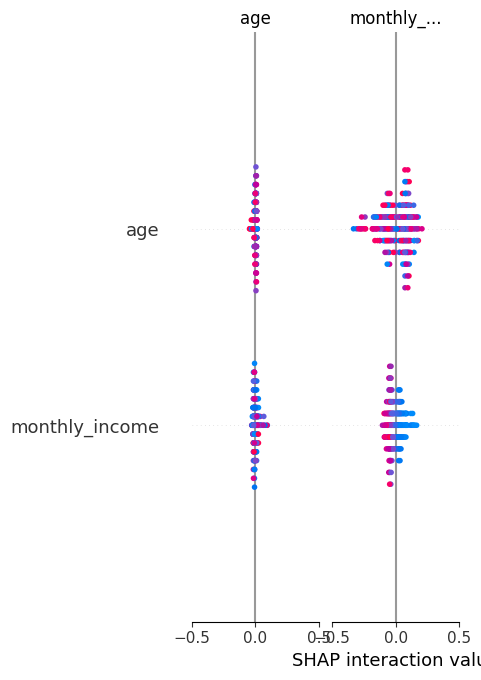

In [38]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)